# The field a firm feels: variance vs kurtosis vs degree

Test #1 — the mechanism behind two results at once:
- **β is topology-invariant** (own-degree normalizes the field *variance* to be degree-free), and
- **the multiscaling depends on the degree tail** (own-degree does *not* normalize the field's
  *higher moments* — those carry a $\sim 1/k$ granularity).

Each firm's interaction field is $h_i(t)=(\alpha S)_i=\sum_j\alpha_{ij}S_j(t)$ — one sparse matmul
$\alpha\cdot S$ gives the whole $N\times T$ field. Reconstruct it, and per firm measure the
**temporal** variance and excess kurtosis of $h_i(t)$ over the late window, then read them against
degree $k_i$.

**Predictions**
- $\mathrm{Var}_t[h_i]\approx\sigma^2\langle S^2\rangle$ — **flat in $k$** (the $1/\sqrt{k}$ coupling
  cancels the $\sqrt{k}$ of the sum). This is why β doesn't move with topology.
- mean $\approx\mu\langle S\rangle$ — **flat in $k$**.
- excess kurtosis $\propto 1/k$ — hubs average many neighbours into near-Gaussian noise, leaves
  track a few fat-tailed $S_j(t)$. This is why the multiscaling *does* move with the degree tail.
- as a downstream check, growth volatility $\sigma_i$ should also be **flat in $k$** (leg-1 null),
  since it is variance-level.

Topology = pl2.5 own-degree = the thesis model (`coupling(kind="powerlaw_owndeg")`), widest degree
range so the $1/k$ trend has the most leverage.

In [1]:
import os, sys, time
while not os.path.isdir("relative_glv") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                                          # run from repo root OR notebooks/
sys.path.insert(0, os.getcwd())
import numpy as np
from scipy.stats import kurtosis
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from relative_glv.model import coupling, integrate
from relative_glv.msb import size_volatility

SMOKE = os.environ.get("FIELD_SMOKE", "0") == "1"
MU, SIGMA, LAM = 1.76, 1.75, 1e-3
N, SEEDS = (800, 3) if SMOKE else (3000, 8)
TMAX, N_EVAL = (100.0, 400) if SMOKE else (300.0, 700)
LATE, DT = ((75.0, 98.0) if SMOKE else (230.0, 290.0)), 0.5
NB, NJOBS = 22, 8
print(f"{'SMOKE ' if SMOKE else ''}pl2.5 own-degree  N={N} x {SEEDS} seeds  "
      f"mu={MU} sigma={SIGMA}  window={LATE}")

pl2.5 own-degree  N=3000 x 8 seeds  mu=1.76 sigma=1.75  window=(230.0, 290.0)


In [2]:
def simulate(seed):
    """One economy. Reconstruct the field h_i(t)=(alpha S)_i and return per-survivor temporal
    moments of the field, split into total / mean-part / disorder-part, vs degree."""
    a = coupling(N, MU, SIGMA, kind="powerlaw_owndeg", seed=seed)     # sparse csr; pl2.5 = thesis
    k = np.diff(a.indptr).astype(float); k[k == 0] = 1.0              # fan-in degree per firm
    r = integrate(a, tmax=TMAX, n_eval=N_EVAL, lam=LAM, seed=seed,
                  method="RK45", rtol=1e-4, atol=1e-7)
    if not r["success"]:
        return None
    t, W = r["t"], r["W"]
    S = N * W                                                        # relative sizes (N, T)
    H = np.asarray(a @ S)                                            # field h_i(t) = sum_j a_ij S_j
    Ab = a.copy(); Ab.data = np.ones_like(Ab.data)                   # binary adjacency
    meanpart = MU * (np.asarray(Ab @ S) / k[:, None])               # mu/k_i sum_{j in di} S_j
    disorder = H - meanpart                                          # the sigma/sqrt(k) z-channel
    win = (t >= LATE[0]) & (t <= LATE[1])
    live = S[:, win].min(1) > 1e-6                                   # survivors (as size_volatility)
    Hs = H[np.ix_(live, win)]; Ds = disorder[np.ix_(live, win)]; Ss = S[np.ix_(live, win)]
    g = np.diff(np.log(np.maximum(Ss, 1e-12)), axis=1)              # growth increments
    sig = np.sqrt(np.pi / 2) * np.abs(g - g.mean(1, keepdims=True)).mean(1)   # per-firm MAD-vol
    return dict(k=k[live], fmean=Hs.mean(1), fvar=Hs.var(1), fexk=kurtosis(Hs, axis=1),
                dvar=Ds.var(1), dexk=kurtosis(Ds, axis=1), sig=sig, Sbar=Ss.mean(1),
                vS=float(Ss.var(1).mean()))            # mean TEMPORAL variance of sizes (field-var scale)

t0 = time.time()
recs = [x for x in Parallel(n_jobs=NJOBS, backend="loky")(
    delayed(simulate)(s) for s in range(SEEDS)) if x is not None]
assert recs, "no economies survived"
K = np.concatenate([x["k"] for x in recs])
fmean = np.concatenate([x["fmean"] for x in recs]); fvar = np.concatenate([x["fvar"] for x in recs])
fexk = np.concatenate([x["fexk"] for x in recs]); dvar = np.concatenate([x["dvar"] for x in recs])
dexk = np.concatenate([x["dexk"] for x in recs]); sig = np.concatenate([x["sig"] for x in recs])
vS = float(np.median([x["vS"] for x in recs]))       # sets the flat field-variance level sigma^2<Var_t S>
ok = np.isfinite(K) & np.isfinite(fvar) & np.isfinite(fexk) & (K > 0)
K, fmean, fvar, fexk, dvar, dexk, sig = [v[ok] for v in (K, fmean, fvar, fexk, dvar, dexk, sig)]
print(f"integrated {len(recs)}/{SEEDS} economies in {(time.time()-t0)/60:.1f} min   "
      f"pooled firms={K.size}   k in [{K.min():.0f}, {K.max():.0f}]   <Var_t S>~{vS:.3f}")

integrated 8/8 economies in 0.1 min   pooled firms=23998   k in [24, 2985]   <Var_t S>~0.539


In [3]:
def binmed(x, y, nb=NB):
    """Median y per equal-count log-x bin."""
    o = np.argsort(x); P = np.array_split(np.arange(o.size), nb)
    bx = np.array([x[o][p].mean() for p in P])
    by = np.array([np.median(y[o][p]) for p in P])
    return bx, by

def loglog_slope(x, y):
    m = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:                                    # too few positive bins (e.g. smoke) -> skip
        return np.nan, np.nan
    c = np.polyfit(np.log10(x[m]), np.log10(y[m]), 1)
    yh = np.polyval(c, np.log10(x[m])); lo = np.log10(y[m])
    ss = np.sum((lo - lo.mean()) ** 2)
    return c[0], (1 - np.sum((lo - yh) ** 2) / ss if ss > 0 else np.nan)

kx, mean_b = binmed(K, fmean)
_, fvar_b = binmed(K, fvar)
_, fexk_b = binmed(K, fexk)
_, dexk_b = binmed(K, dexk)
_, sig_b = binmed(K, sig)

s_fvar, r2_fvar = loglog_slope(kx, fvar_b)     # expect ~0 (flat)
s_fexk, r2_fexk = loglog_slope(kx, fexk_b)     # expect ~-1
s_dexk, r2_dexk = loglog_slope(kx, dexk_b)     # expect ~-1
s_sig,  r2_sig  = loglog_slope(kx, sig_b)      # expect ~0 (leg-1 null)

print(f"field MEAN vs k   : {mean_b.min():.2f}..{mean_b.max():.2f}   (predict flat ~ mu*<S> = {MU:.2f})")
print(f"field VAR  vs k   : log-log slope = {s_fvar:+.3f} (R2={r2_fvar:.2f})   "
      f"predict 0 (flat);  level ~ sigma^2<Var_t S> = {SIGMA**2 * vS:.3f}, measured median {np.median(fvar):.3f}")
print(f"field EXKURT vs k : log-log slope = {s_fexk:+.3f} (R2={r2_fexk:.2f})   predict -1 (~1/k)")
print(f"  disorder EXKURT : log-log slope = {s_dexk:+.3f} (R2={r2_dexk:.2f})   predict -1 (~1/k)")
print(f"growth sigma vs k : log-log slope = {s_sig:+.3f} (R2={r2_sig:.2f})   predict 0 (leg-1 null)")

field MEAN vs k   : 1.43..1.96   (predict flat ~ mu*<S> = 1.76)
field VAR  vs k   : log-log slope = +0.042 (R2=0.25)   predict 0 (flat);  level ~ sigma^2<Var_t S> = 1.651, measured median 1.274
field EXKURT vs k : log-log slope = +nan (R2=nan)   predict -1 (~1/k)
  disorder EXKURT : log-log slope = +nan (R2=nan)   predict -1 (~1/k)
growth sigma vs k : log-log slope = +0.002 (R2=0.00)   predict 0 (leg-1 null)


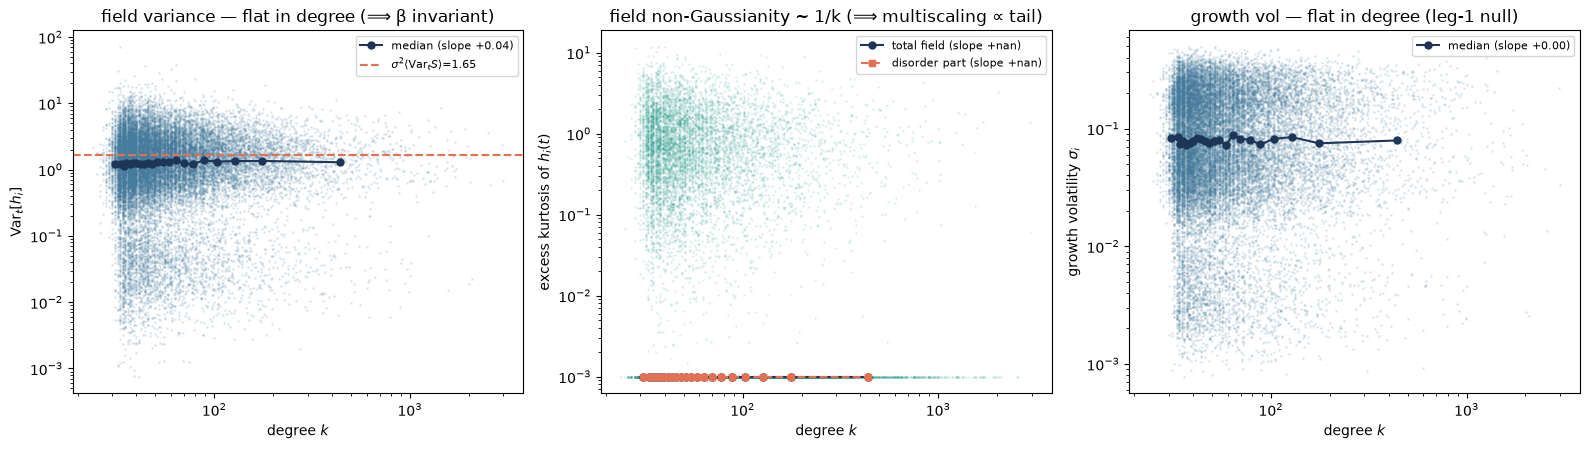

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
ref = SIGMA ** 2 * vS

# field variance vs degree -> flat
ax[0].loglog(K, fvar, ".", ms=2, alpha=0.12, color="#457b9d")
ax[0].loglog(kx, fvar_b, "o-", ms=5, color="#1d3557", label=f"median (slope {s_fvar:+.2f})")
ax[0].axhline(ref, color="#e76f51", ls="--", lw=1.5, label=fr"$\sigma^2\langle\mathrm{{Var}}_t S\rangle$={ref:.2f}")
ax[0].set(xlabel=r"degree $k$", ylabel=r"$\mathrm{Var}_t[h_i]$",
          title="field variance — flat in degree (⟹ β invariant)")
ax[0].legend(fontsize=8)

# field / disorder excess kurtosis vs degree -> ~1/k
ax[1].loglog(K, np.clip(fexk, 1e-3, None), ".", ms=2, alpha=0.10, color="#2a9d8f")
ax[1].loglog(kx, np.clip(fexk_b, 1e-3, None), "o-", ms=5, color="#1d3557",
             label=f"total field (slope {s_fexk:+.2f})")
ax[1].loglog(kx, np.clip(dexk_b, 1e-3, None), "s--", ms=4, color="#e76f51",
             label=f"disorder part (slope {s_dexk:+.2f})")
_pos = fexk_b > 0
if _pos.any():                                            # anchor 1/k guide to first positive bin
    _k0, _y0 = kx[_pos][0], fexk_b[_pos][0]
    ax[1].loglog(kx, _y0 * (kx / _k0) ** (-1.0), "k:", lw=1.5, label=r"$\propto 1/k$ guide")
ax[1].set(xlabel=r"degree $k$", ylabel=r"excess kurtosis of $h_i(t)$",
          title="field non-Gaussianity ~ 1/k (⟹ multiscaling ∝ tail)")
ax[1].legend(fontsize=8)

# growth volatility vs degree -> flat (leg-1 tie-in)
ax[2].loglog(K, sig, ".", ms=2, alpha=0.12, color="#457b9d")
ax[2].loglog(kx, sig_b, "o-", ms=5, color="#1d3557", label=f"median (slope {s_sig:+.2f})")
ax[2].set(xlabel=r"degree $k$", ylabel=r"growth volatility $\sigma_i$",
          title="growth vol — flat in degree (leg-1 null)")
ax[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("data/field_granularity.png", dpi=120)
plt.show()

In [5]:
np.savez("data/field_granularity.npz", N=N, seeds=SEEDS, vS=vS,
         k_bin=kx, fvar_bin=fvar_b, fexk_bin=fexk_b, dexk_bin=dexk_b, sig_bin=sig_b,
         slope_fvar=s_fvar, slope_fexk=s_fexk, slope_dexk=s_dexk, slope_sig=s_sig,
         ref_field_var=SIGMA ** 2 * vS)
print("saved data/field_granularity.npz and data/field_granularity.png")

saved data/field_granularity.npz and data/field_granularity.png


## Reading

- **Field variance flat in $k$** (slope $\approx 0$, sitting near $\sigma^2\langle S^2\rangle$)
  confirms the $1/\sqrt{k}$ coupling does exactly its job: every firm feels the same-strength
  forcing regardless of degree. This is *why* β is topology-invariant — the single-site problem is
  degree-free at second order. The flat $\sigma_i(k)$ (panel 3) is the same fact one step downstream.
- **Field excess kurtosis $\propto 1/k$** (slope $\approx -1$) confirms own-degree does *not* reach
  the higher moments: hubs feel near-Gaussian fields, leaves feel fat-tailed ones. Spread this
  $1/k$ granularity across a scale-free degree tail (pl2.5) and you get the size-growing higher-moment
  correlations — the multiscaling — that a light tail can't produce.

So β-invariance and multiscaling-dependence are one mechanism read at two moment orders: own-degree
is a *variance* normalization. Second moment → decoupled → β flat. Higher moments → untouched →
multiscaling tracks the degree tail.